<a href="https://colab.research.google.com/github/pzedros/metodos_numericos/blob/main/Aula_3_Otimiza%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Razão Áurea

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo a função
def f(x):
    return (x**2)/10 - 2*np.sin(x)

# Constantes da razão áurea
phi = (1 + np.sqrt(5)) / 2  # razão áurea

# Intervalo inicial
xl = 0
xu = 4

# Critério de parada: erro percentual
n = 6
Eppara = 0.5 * 10**(2 - n)  # 0.5*10^(2-6) = 0.0005%

# Inicializa os pontos internos
d = (phi-1) * (xu - xl)
x1 = xl + d
x2 = xu - d
Ea = np.inf  # erro inicial

# Loop até atingir o erro desejado
while Ea > Eppara:

    if f(x1) < f(x2):
        xl = x2
        x2 = x1
        d = (phi-1) * (xu - xl)
        x1 = xl + d
    elif f(x2) < f(x1):
        xu = x1
        x1 = x2
        d = (phi-1) * (xu - xl)
        x2 = xu - d

    # Atualiza o valor ótimo
    xotm = (xl + xu) / 2

    # Calcula erro aproximado
    Ea = abs((2 - phi) * ((xu - xl) / xotm) * 100)

# Resultado final
print(f"x ótimo ≈ {xotm:.6f}")
print(f"f(x ótimo) ≈ {f(xotm):.6f}")
print(f"Erro aproximado (%) ≈ {Ea:.2e}")


x ótimo ≈ 1.427552
f(x ótimo) ≈ -1.775726
Erro aproximado (%) ≈ 3.56e-05


Interpolação Quadrática

1.0254718960162554
7.150178024276214
2.138606945081053
1.1327312035470758
0.6960831926042277
0.00021333110030260553
9.59320470630378e-05
4.6582086303762526e-08
o valor do x4_new é: 1.4275517788976004


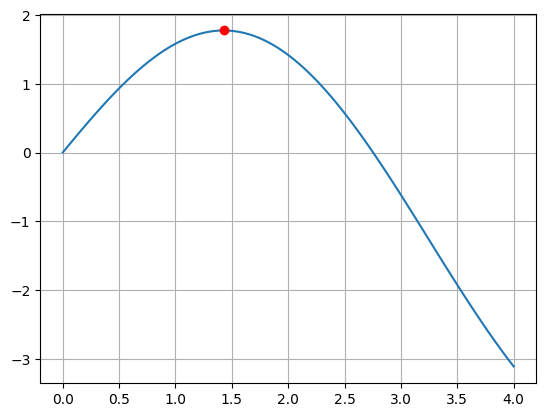

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return - x**2/10 + 2*np.sin(x)

x1 = 0
x2 = 1
x3 = 4
x4_old = x2 - 1/2 * (((x2 - x1)**2 * (f(x2) - f(x3)) - (x2 - x3)**2 * (f(x2) - f(x1))) / ((x2 - x1) * (f(x2) - f(x3)) - (x2 - x3) * (f(x2) - f(x1))))

n = 6
Eppara = 0.5*10**(2-n)
Epest = 100

while Epest >= Eppara:
  if f(x4_old) > f(x2):
    x1 = x2
    x2 = x4_old
  else:
    x3 = x2
    x2 = x4_old

  x4_new = x2 - 1/2 * (((x2 - x1)**2 * (f(x2) - f(x3)) - (x2 - x3)**2 * (f(x2) - f(x1))) / ((x2 - x1) * (f(x2) - f(x3)) - (x2 - x3) * (f(x2) - f(x1))))

  Epest = abs((x4_new - x4_old)/(x4_new)*100)

  x4_old = x4_new
  print(Epest)

print(f'o valor do x4_new é: {x4_new}')

x = np.linspace(0, 4, 100)

plt.plot(x, f(x))
plt.plot(x4_new, f(x4_new), 'ro')
plt.grid(True)

fminbound

In [ ]:
from scipy import optimize
import numpy as np

def func(x):
  return x**2 / 10 - 2*np.sin(x)

x1 = 0
x2 = 4

x_opt = optimize.fminbound(func, x1, x2)
print(x_opt)

1.4275517992922275


Otimização Multidimensional

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import optimize

#define as variaveis x1 e x2 usando o np.linspace
x1 = np.linspace(-2, 0, 30)
x2 = np.linspace(0, 3, 50)

#criar as combinações de x1 e x2 usando meshgrid
X1, X2 = np.meshgrid(x1, x2)

#calcula os valores da função f(x1, x2) para cada par de ponto (X1, X2)
Z = 2 + X1 - X2 + 2*X1**2 + 2*X1*X2 + X2**2

print(Z)

[[8.         7.52675386 7.0725327  ... 1.90011891 1.94054697 2.        ]
 [7.69762599 7.23282461 6.7870482  ... 1.82575334 1.87462616 1.94252395]
 [7.40274885 6.94639223 6.50906058 ... 1.75888465 1.81620223 1.89254477]
 ...
 [1.89254477 1.81620223 1.75888465 ... 6.50906058 6.94639223 7.40274885]
 [1.94252395 1.87462616 1.82575334 ... 6.7870482  7.23282461 7.69762599]
 [2.         1.94054697 1.90011891 ... 7.0725327  7.52675386 8.        ]]


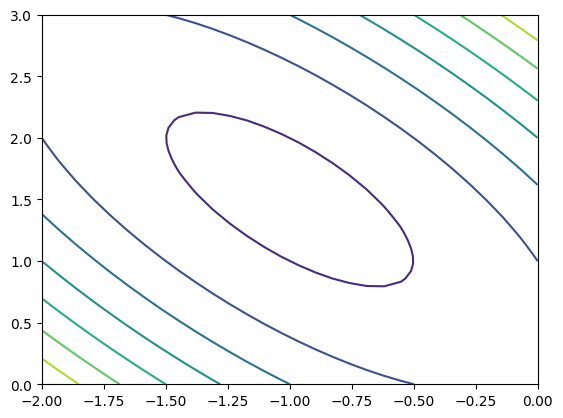

In [ ]:
#curva de nivel (verificar extreemo de função)
plt.contour(X1, X2, Z)

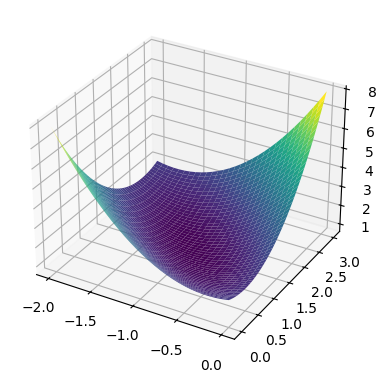

In [ ]:
#grafico de superficie
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(121, projection='3d')
cs = ax.plot_surface(X1, X2, Z,cmap='viridis')

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import optimize

def func(x):
  x1 = x[0]   #descondensar o vetor, o x1 vai p primeira posição e o x2 é a segunda
  x2 = x[1]
  return 2 + x1 - x2 + 2*x1**2 + 2*x1*x2 + x2**2

x0 = [0, 0]

x_opt = optimize.minimize(func, x0)
print(x_opt)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.7500000000000002
        x: [-1.000e+00  1.500e+00]
      nit: 4
      jac: [ 0.000e+00 -2.980e-08]
 hess_inv: [[ 5.000e-01 -5.000e-01]
            [-5.000e-01  1.000e+00]]
     nfev: 18
     njev: 6
